In [26]:
# --- Setup & imports ---

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from numpy.fft import rfft, rfftfreq
from scipy.signal import get_window

# Paths
MIC_XLSX      = Path("Mic_locations.xlsx")
PRESSURE_XLSX = Path("Pressure_signal_received_by_microphones.xlsx")

# Physical/constants
c        = 343.0                 # speed of sound 
f0       = 2000.0                # target frequency 
z_focus  = 1.0                   # z coordinate [m]
fs_default = 48000.0             # fallback sampling rate because 48kHz is the standard acoustic sampling rate in literature used to avoid aliasing
block_sec  = 1.0                 # CSM block length [s] for averaging around f0
win_name   = "hann"              # Window type

# Imaging grid (square around array center)
grid_extent = 0.20               # +/- [m]
grid_step   = 0.005              # [m]

# Plotting
plt.rcParams.update({"figure.figsize":(6,5), "image.cmap":"viridis"})


In [35]:
# --- Load mic and center mic coordinates + Load recorded pressure signals ---

def load_mics_centered(path: Path):
    """
    Load mic coordinates (x,y[,(z)]) from Excel, return (M,3) array centered at centroid.
    z is optional; if absent, set z=0. Assumes units are meters.
    """
    df = pd.read_excel(path, engine="openpyxl")
    cols = [str(c).strip().lower() for c in df.columns]     # For consistency
    df.columns = cols

    # pick the first col that startswith 'x', 'y', 'z'
    def pick(colprefix, default=None):
        cands = [c for c in cols if c.startswith(colprefix)]
        if cands: return df[cands[0]].to_numpy(float)
        return default

    x = pick("x")
    y = pick("y")
    z = pick("z", default=np.zeros_like(x))

    coords = np.column_stack([x,y,z])
    centroid = coords.mean(axis=0, keepdims=True)
    centered = coords - centroid
    return centered, centroid.ravel()

def load_pressures(path: Path):
    """
    Load pressure time series from Excel.
    Expect microphones in columns (or rows) – detect shape.
    If an 'fs' column or sheet not provided, fallback to fs_default.
    Return p(M,N), fs
    """
    df = pd.read_excel(path, engine="openpyxl")

    fs = fs_default

    arr = df.to_numpy(float)

    # Ensure array shape (M,N): M mics (rows), N samples (cols)
    # Heuristic: if rows >> cols we assume (N,M), so transpose.
    if arr.shape[0] > arr.shape[1]:
        # assume columns are mics -> transpose to (M,N)
        p = arr.T
    else:
        p = arr
    return p, fs


In [ ]:
# --- Frequency-domain DAS using the CSM (single frequency bin) ---
# References for formulas:
#  - Conventional/DAS with amplitude & delay factors and frequency-domain form bf(x, ω) & power map w* C w. Ref: Acoustic Source Localization and Beamforming: Theory and Practice (J. Chen, R.E. Hudson, and K. Yao)
#  - Near-field steering with spherical decay 1/(4πr) and phase exp(-j k r). Ref: Acoustic Beamforming Algorithms and Their Applications in Environmental Noise (G. Licitra, P. Ascari, M. Fredianelli, and S. Bianco)

def steering_vector_nearfield(mics_xyz, grid_xyz, f, c=343.0):
    """
    Build near-field steering vector g for a single grid point (spherical waves).
    g_m = (1/(4π r_m)) * exp(-j k r_m)
    No flow refraction; free-space monopole model.
    """
    k = 2*np.pi*f/c
    r = np.linalg.norm(mics_xyz - grid_xyz, axis=1)  # distances mic->grid
    r = np.maximum(r, 1e-9) # Avoid r=0
    g = (1.0/(4.0*np.pi*r)) * np.exp(-1j * k * r)
    return g

def normalized_weight(g):
    """
      w = g / ||g||^2
    """
    denom = np.vdot(g, g)  # g^H g
    if denom == 0: return g
    return g / denom

def csm_from_blocks(p, fs, f0, block_sec=1.0, window="hann", band_hz=5.0):
    """
    Build a Cross-Spectral Matrix (CSM) around a narrowband f0, averaged over time blocks.
         C_b(f0) = x_b(f0)x_b^H(f0) and C(f0) = 1/B \sum_{b=1}^B C_b(f0). b -> block size B -> total # blocks
    Returns C (M x M complex), effective frequency f_bin used.
    """
    M, N = p.shape
    L = int(round(block_sec*fs))
    L = min(L, N)  
    step = L  
    w = get_window(window, L, fftbins=True)
    w2 = (w**2).sum()

    num = int(np.floor((N-L)/step))+1   # number of time blocks
    C = np.zeros((M,M), dtype=complex)
    f_bin_sel = None

    for b in range(num):
        seg = p[:, b*step:b*step+L] * w  # broadcast over rows
        # FFT along time for each mic
        X = rfft(seg, axis=1)
        freqs = rfftfreq(L, 1.0/fs)
        # pick the closest bin to f0
        if f_bin_sel is None:
            f_bin_sel = int(np.argmin(np.abs(freqs - f0)))   
        band_idx = np.where(np.abs(freqs - f0) <= band_hz)[0]
        if band_idx.size == 0: band_idx = np.array([f_bin_sel])
        
        # Build and accumulate the CSM
        for k in band_idx:
            xk = X[:, k] / np.sqrt(w2)  # normalize to obtain the true pressure amplitude
            C += np.outer(xk, np.conj(xk))
    C /= (num * max(1, band_idx.size))
    f_eff = freqs[f_bin_sel]        # the FFT frequency closest to f0
    return C, f_eff


In [44]:
# --- Imaging map helpers ---

def make_grid_xy(extent=0.20, step=0.005):
    xs = np.arange(-extent, extent+1e-12, step)
    ys = np.arange(-extent, extent+1e-12, step)
    XX, YY = np.meshgrid(xs, ys, indexing="xy")
    return XX, YY

def das_power_map(mics_xyz, C, f, z_plane=1.0, grid_extent=0.2, grid_step=0.005, c=343.0):
    XX, YY = make_grid_xy(grid_extent, grid_step)
    Z  = np.full_like(XX, z_plane)
    Mx = mics_xyz

    P = np.zeros_like(XX, dtype=float)

    for i in range(XX.shape[0]):
        for j in range(XX.shape[1]):
            gp = steering_vector_nearfield(Mx, np.array([XX[i,j], YY[i,j], Z[i,j]]), f, c)
            w  = normalized_weight(gp)
            P[i,j] = np.real(np.vdot(w, C @ w))  # w^H C w
    return XX, YY, P

def plot_map(XX, YY, P, title="", clim_db=None, savepath=None):
    eps = 1e-30
    L = 20*np.log10(np.maximum(P, eps)/np.max(P))
    fig, ax = plt.subplots()
    im = ax.imshow(L, extent=[XX.min(), XX.max(), YY.min(), YY.max()],
                   origin="lower", aspect="equal")
    cbar = plt.colorbar(im)
    cbar.set_label("dB (rel. max)")
    ax.set_xlabel("x [m]"); ax.set_ylabel("y [m]")
    ax.set_title(title)
    if clim_db is not None:
        im.set_clim([-clim_db, 0])
    if savepath:
        plt.savefig(savepath, bbox_inches="tight", dpi=150)
    plt.show()


In [ ]:
# --- Synthetic data generator for point sources ---
# Model: p_m(t) = Σ_s A_s * sin(2π f0 (t - r_ms/c)) / (4π r_ms)
# Supports multiple point sources and optional white noise.

def synth_point_sources(mics_xyz, fs, dur, sources, c=343.0, noise_std=0.0):
    """
    sources: list of dicts: {"pos": [x,y,z], "amp": 0.1, "freq": 2000.0, "phase": 0.0}
    returns p(M,N)
    """
    M = mics_xyz.shape[0]
    N = int(round(fs*dur))
    t = np.arange(N)/fs
    p = np.zeros((M,N), dtype=float)
    for s in sources:
        pos   = np.array(s["pos"], float)
        amp   = float(s.get("amp", 0.1))
        freq  = float(s.get("freq", f0))
        phase = float(s.get("phase", 0.0))
        r = np.linalg.norm(mics_xyz - pos, axis=1)  # M
        delay = r / c
        # broadcast: sin(2π f (t - delay_m))
        arg = 2*np.pi*freq*(t[None,:] - delay[:,None]) + phase
        p += (amp / (4*np.pi*r))[:,None] * np.sin(arg)
    if noise_std > 0:
        p += noise_std*np.random.randn(M,N)
    return p


In [46]:
# --- Load data and build CSM for the measured case (Experiment A) ---

mics_xyz, centroid = load_mics_centered(MIC_XLSX)
print(f"Loaded {mics_xyz.shape[0]} microphones. Array centroid (original): {centroid} [m]")

p_meas, fs_meas = load_pressures(PRESSURE_XLSX)
print(f"Loaded pressure signals: shape {p_meas.shape}, fs={fs_meas:.1f} Hz")

# Build narrowband CSM around f0
C_meas, f_eff = csm_from_blocks(
    p_meas, fs_meas, f0, block_sec=block_sec, window=win_name, band_hz=5.0
)
print(f"CSM built at ~{f_eff:.1f} Hz")


Loaded 32 microphones. Array centroid (original): [-5.20417043e-18 -3.72965547e-17  0.00000000e+00] [m]
Loaded pressure signals: shape (32, 131073), fs=48000.0 Hz
CSM built at ~2000.0 Hz


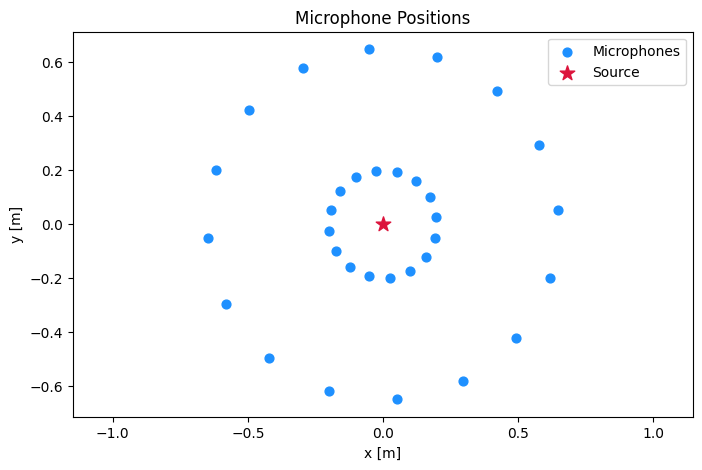

In [47]:
# --- Plot microphone positions ---

import matplotlib.pyplot as plt

def plot_mic_array(mics_xyz, title="Microphone Array", show_source=True, src_pos=(0,0,1.0)):
    plt.figure(figsize=(8, 5))
    plt.scatter(mics_xyz[:,0], mics_xyz[:,1], s=40, c='dodgerblue', label='Microphones')
    if show_source:
        plt.scatter(src_pos[0], src_pos[1], c='crimson', marker='*', s=120, label='Source')
    plt.xlabel('x [m]')
    plt.ylabel('y [m]')
    plt.title(title)
    plt.axis('equal')
    plt.grid(False)
    plt.legend()
    plt.show()

# Call after loading mic coordinates
plot_mic_array(mics_xyz, title="Microphone Positions", show_source=True, src_pos=(0,0,1.0))


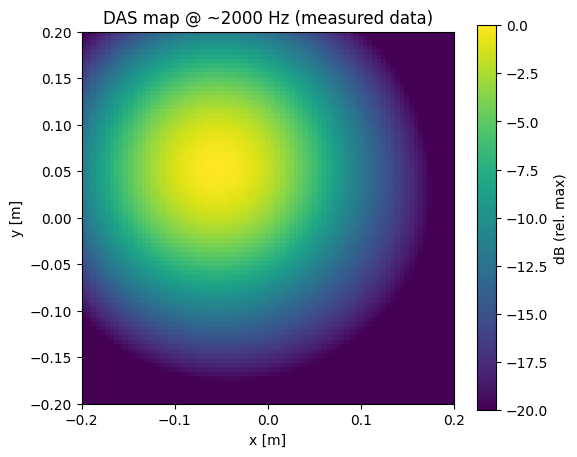

In [48]:
# --- Experiement 1: Validate DAS map on measured data (source at [0,0,1]) ---

XX, YY, P_meas = das_power_map(
    mics_xyz, C_meas, f_eff, z_plane=z_focus,
    grid_extent=grid_extent, grid_step=grid_step, c=c
)

plot_map(XX, YY, P_meas, 
         title=f"DAS map @ ~{f_eff:.0f} Hz (measured data)",
         clim_db=20, savepath="DAS_measured_validation.png")


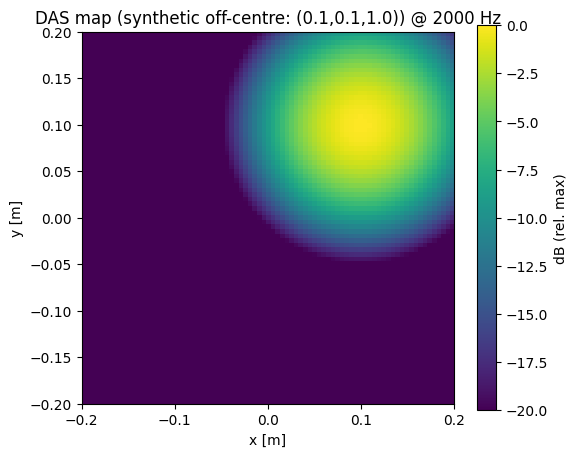

In [49]:
# --- Experiment 2: Off-centre single point (synthetic) e.g., (0.1, 0.1, 1.0) ---

# Synthesize signals on the same array to check algorithmic robustness
dur = 1.0  # seconds
sources_B = [{"pos":[0.10, 0.10, z_focus], "amp":0.1, "freq":f0}]
p_B = synth_point_sources(mics_xyz, fs_default, dur, sources_B, c=c, noise_std=0.0)

C_B, f_eff_B = csm_from_blocks(p_B, fs_default, f0, block_sec=dur, window="hann", band_hz=2.0)

XX, YY, P_B = das_power_map(
    mics_xyz, C_B, f_eff_B, z_plane=z_focus,
    grid_extent=grid_extent, grid_step=grid_step, c=c
)

plot_map(XX, YY, P_B,
         title=f"DAS map (synthetic off-centre: (0.1,0.1,1.0)) @ {f_eff_B:.0f} Hz",
         clim_db=20, savepath="DAS_offcentre.png")
